# ASTRA-LM Experiment Analysis
Use this notebook to analyze and compare results from different experiment runs.

In [413]:
import pandas as pd
import matplotlib.pyplot as plt
import os
import glob
from IPython.display import display

## Select Experiment Directory
You can analyze either a baseline comparison run (from `outputs/compare_gpt_vs_vayusphere`) or a VayuSphere v0.2 ablation run (from `outputs/ablate_v2`). The cell below auto-detects the latest run of both types and defaults to the most recent one.

In [414]:
# Detect if running from the 'notebooks' directory or the project root
base_dir = ".." if os.path.basename(os.getcwd()) == "notebooks" else "."

compare_path = os.path.join(base_dir, "outputs", "compare_gpt_vs_vayusphere")
ablate_path = os.path.join(base_dir, "outputs", "ablate_v2")

compare_runs = sorted(glob.glob(os.path.join(compare_path, "*")))
ablate_runs = sorted(glob.glob(os.path.join(ablate_path, "*")))

latest_compare = compare_runs[-1] if compare_runs else None
latest_ablate = ablate_runs[-1] if ablate_runs else None

print("Available runs:")
if latest_compare:
    print(f"  [compare] Latest Comparison: {latest_compare}")
if latest_ablate:
    print(f"  [ablate]  Latest Ablation:   {latest_ablate}")

# Default to the most recently modified run directory
run_to_analyze = None
if latest_compare and latest_ablate:
    if os.path.getmtime(latest_compare) > os.path.getmtime(latest_ablate):
        run_to_analyze = latest_compare
    else:
        run_to_analyze = latest_ablate
elif latest_compare:
    run_to_analyze = latest_compare
elif latest_ablate:
    run_to_analyze = latest_ablate

# Alternatively, manual override (uncomment and customize):
# # run_to_analyze = os.path.join(ablate_path, "your_run_here")

if run_to_analyze:
    print(f"\nAnalyzing: {run_to_analyze}")
else:
    print("\nNo experiment runs found.")

Available runs:
  [compare] Latest Comparison: ..\outputs\compare_gpt_vs_vayusphere\20260621_212027_seed42_scratch_fair
  [ablate]  Latest Ablation:   ..\outputs\ablate_v2\my_ablation_run

Analyzing: ..\outputs\ablate_v2\my_ablation_run


## Load Ablation Results Summary
If the selected run is a VayuSphere v0.2 ablation study, it contains a summary CSV (`ablation_results.csv`) of all trained model variants.

In [415]:
if run_to_analyze:
    summary_file = os.path.join(run_to_analyze, "ablation_results.csv")
    if os.path.exists(summary_file):
        print("--- Ablation Results Summary Table ---")
        df_summary = pd.read_csv(summary_file)
        display(df_summary)
    else:
        print("No ablation summary table (ablation_results.csv) found in this run.")

--- Ablation Results Summary Table ---


,name,loss,perplexity,params,peak_mem_mb,total_time_sec,tokens_per_sec,max_steps,eval_points
0,A_baseline,6.2849,536.4036,16999430,642.370605,287.472015,17810.429325,10000,10
1,B_learned_temp,6.2813,534.4641,16999478,645.385254,303.108412,16891.646015,10000,10
2,C_vs_scale_v0.1,6.2828,535.2853,17005574,654.212402,477.566724,10721.014969,10000,10
3,D_vs_scale_topk8,6.2775,532.4502,17005574,654.212402,522.954682,9790.523295,10000,10
4,E_vs_tangent_pre_rope_topk8,6.2810,534.3187,17005574,668.063965,646.655683,7917.660257,10000,10
5,F_vs_tangent_scale_pre_rope_topk8,6.2829,535.3602,17005574,673.923340,738.758520,6930.546126,10000,10


## Load and Plot Metrics

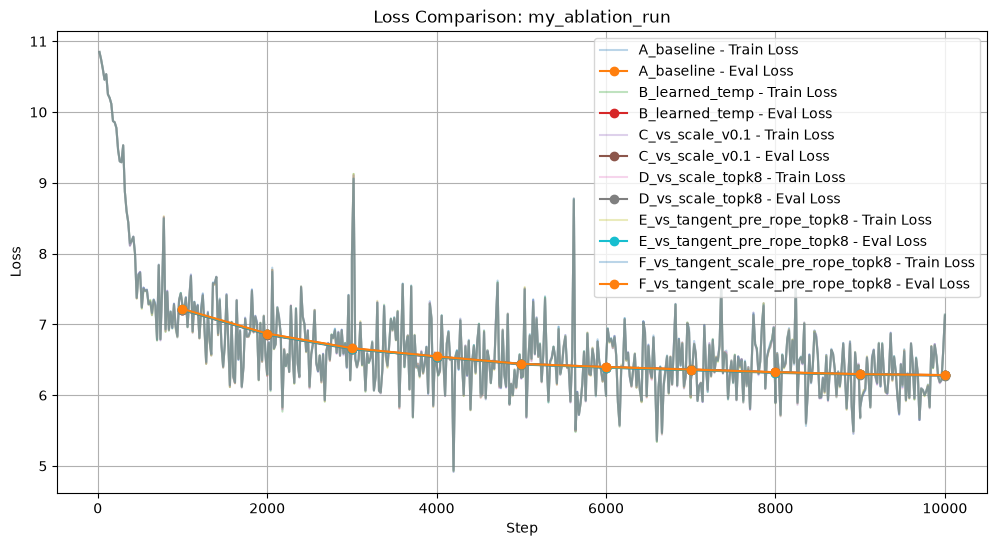

In [416]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    
    plt.figure(figsize=(12, 6))
    
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            # Plot loss
            plt.plot(df['step'], df['loss'].interpolate(), label=f"{subdir} - Train Loss", alpha=0.3)
            
            # Plot eval loss
            eval_df = df.dropna(subset=['eval_loss'])
            if not eval_df.empty:
                plt.plot(eval_df['step'], eval_df['eval_loss'], marker='o', label=f"{subdir} - Eval Loss")
    
    plt.title(f"Loss Comparison: {os.path.basename(run_to_analyze)}")
    plt.xlabel("Step")
    plt.ylabel("Loss")
    plt.legend()
    plt.grid(True)
    plt.show()

## VayuSphere Diagnostics
If VayuSphere was active, we can check its gate and gradient statistics.


--- VayuSphere Diagnostics for C_vs_scale_v0.1 ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio
504,9920,0.000144,-0.000081,0.001794,3.465467,0.121928
505,9940,0.000072,0.000086,0.002014,3.465600,0.106160
506,9960,0.000126,-0.000036,0.001736,3.465518,0.118164
507,9980,0.000041,-0.000039,0.001781,3.465589,0.110799
508,10000,0.000087,-0.000024,0.001995,3.465600,0.107402


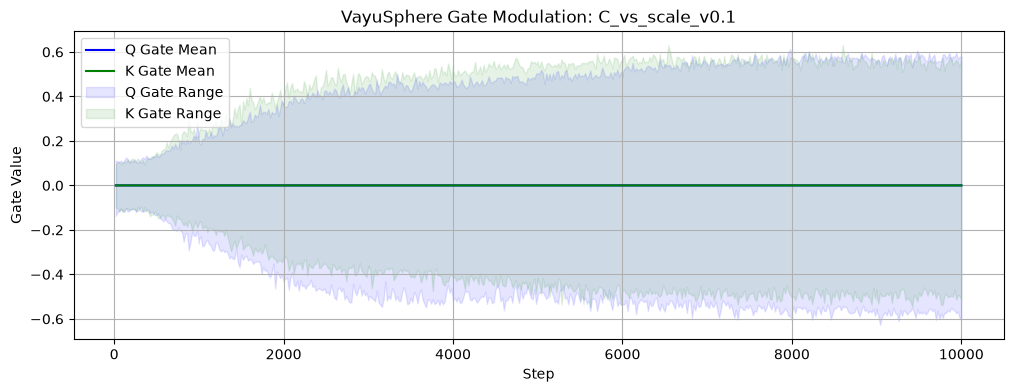

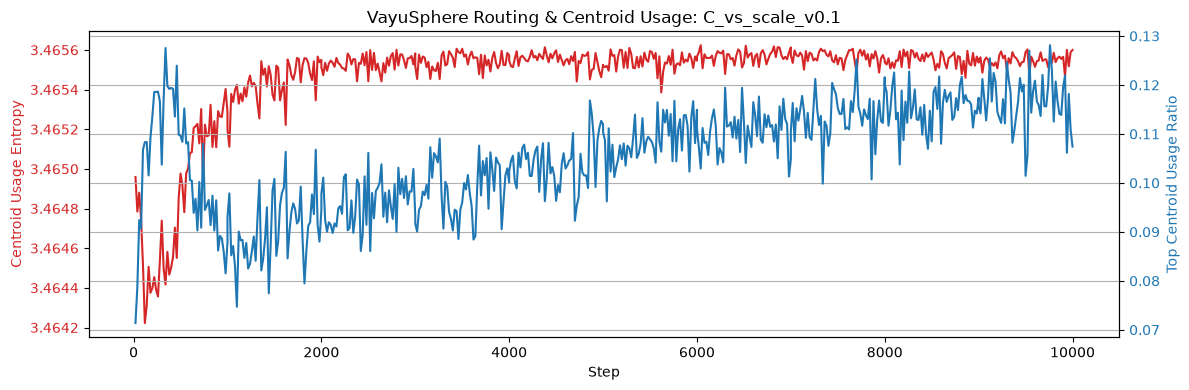


--- VayuSphere Diagnostics for D_vs_scale_topk8 ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio
504,9920,0.000199,0.000462,0.003051,3.257769,0.195801
505,9940,0.000240,0.000133,0.004426,3.287109,0.167216
506,9960,0.000177,0.000557,0.003060,3.259594,0.207682
507,9980,0.000162,0.000103,0.003385,3.281369,0.167847
508,10000,0.000237,-0.000243,0.004025,3.287544,0.165914


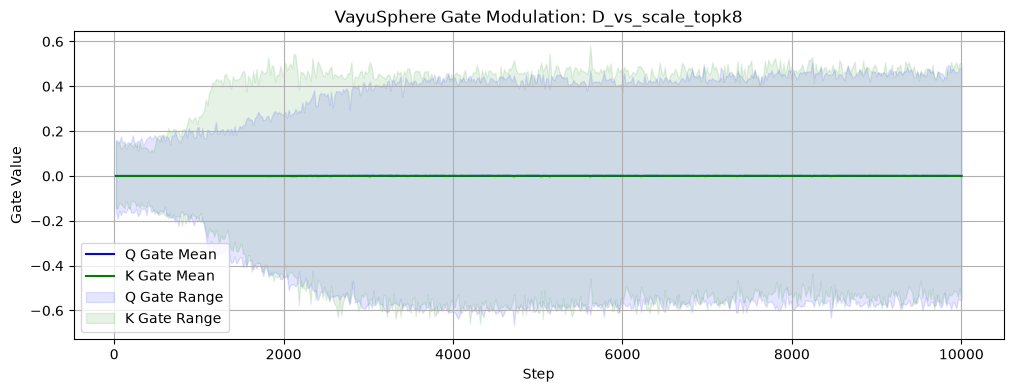

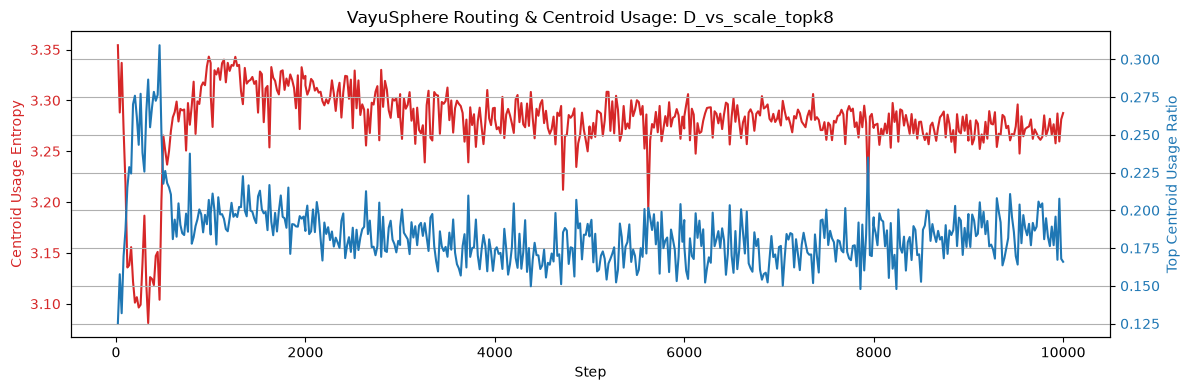


--- VayuSphere Diagnostics for F_vs_tangent_scale_pre_rope_topk8 ---


,step,vs_q_gate_mean,vs_k_gate_mean,vs_centroid_grad_norm,vs_centroid_usage_entropy,vs_top_centroid_usage_ratio
504,9920,0.000136,0.000099,0.019400,3.312090,0.208822
505,9940,0.000119,0.000119,0.022295,3.331801,0.179057
506,9960,0.000149,0.000118,0.021208,3.313187,0.210470
507,9980,0.000118,0.000096,0.018395,3.334391,0.181763
508,10000,0.000135,0.000097,0.023048,3.328030,0.175659


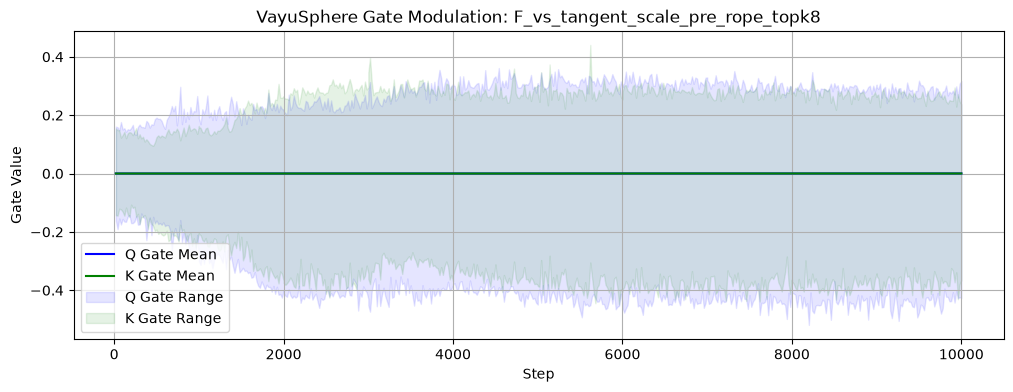

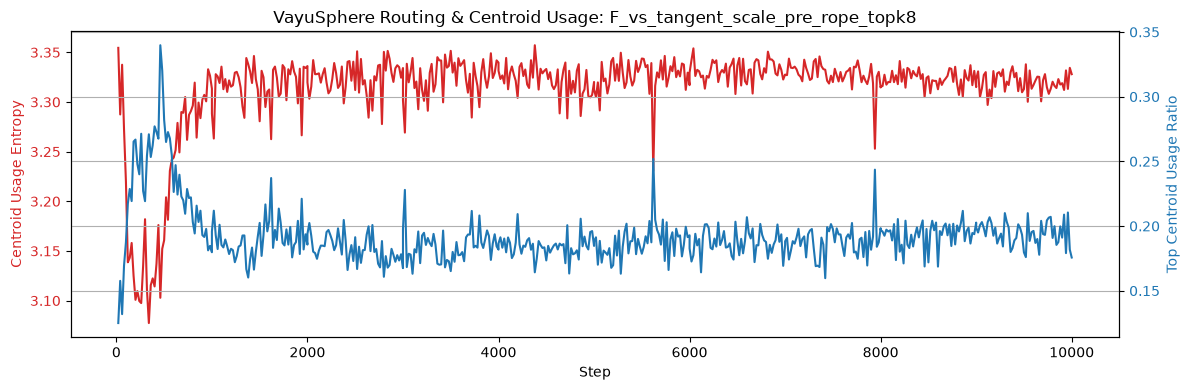

In [417]:
if run_to_analyze:
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_gate_mean' in df and not df['vs_q_gate_mean'].dropna().empty:
                print(f"\n--- VayuSphere Diagnostics for {subdir} ---")
                
                # Support both old and new column names
                grad_col = 'vs_centroid_grad_norm' if 'vs_centroid_grad_norm' in df else 'vs_centroid_grad_norm_mean'
                
                cols = ['step', 'vs_q_gate_mean', 'vs_k_gate_mean', grad_col]
                for extra_col in ['vs_centroid_usage_entropy', 'vs_top_centroid_usage_ratio']:
                    if extra_col in df:
                        cols.append(extra_col)
                        
                display(df[cols].dropna().tail())
                
                # Plot Gate Means
                plt.figure(figsize=(12, 4))
                plt.plot(df['step'], df['vs_q_gate_mean'].interpolate(), label='Q Gate Mean', color='blue')
                plt.plot(df['step'], df['vs_k_gate_mean'].interpolate(), label='K Gate Mean', color='green')
                
                # Plot Min/Max envelopes if available
                if 'vs_q_gate_min' in df and 'vs_q_gate_max' in df:
                    q_min_clean = df['vs_q_gate_min'].interpolate()
                    q_max_clean = df['vs_q_gate_max'].interpolate()
                    plt.fill_between(df['step'], q_min_clean, q_max_clean, alpha=0.1, color='blue', label='Q Gate Range')
                if 'vs_k_gate_min' in df and 'vs_k_gate_max' in df:
                    k_min_clean = df['vs_k_gate_min'].interpolate()
                    k_max_clean = df['vs_k_gate_max'].interpolate()
                    plt.fill_between(df['step'], k_min_clean, k_max_clean, alpha=0.1, color='green', label='K Gate Range')
                
                plt.title(f"VayuSphere Gate Modulation: {subdir}")
                plt.xlabel("Step")
                plt.ylabel("Gate Value")
                plt.legend()
                plt.grid(True)
                plt.show()
                
                # Plot Centroid Usage Diagnostics if available
                if 'vs_centroid_usage_entropy' in df or 'vs_top_centroid_usage_ratio' in df:
                    fig, ax1 = plt.subplots(figsize=(12, 4))
                    
                    color = 'tab:red'
                    ax1.set_xlabel('Step')
                    ax1.set_ylabel('Centroid Usage Entropy', color=color)
                    if 'vs_centroid_usage_entropy' in df:
                        ax1.plot(df['step'], df['vs_centroid_usage_entropy'].interpolate(), color=color, label='Entropy')
                    ax1.tick_params(axis='y', labelcolor=color)
                    
                    ax2 = ax1.twinx()
                    color = 'tab:blue'
                    ax2.set_ylabel('Top Centroid Usage Ratio', color=color)
                    if 'vs_top_centroid_usage_ratio' in df:
                        ax2.plot(df['step'], df['vs_top_centroid_usage_ratio'].interpolate(), color=color, label='Top Ratio')
                    ax2.tick_params(axis='y', labelcolor=color)
                    
                    plt.title(f"VayuSphere Routing & Centroid Usage: {subdir}")
                    fig.tight_layout()
                    plt.grid(True)
                    plt.show()

## VayuSphere v0.2 Ablation Comparisons
If this run is an ablation study, compare the performance, throughput, memory overhead, and parameter count of all variants side-by-side, along with routing confidence metrics.

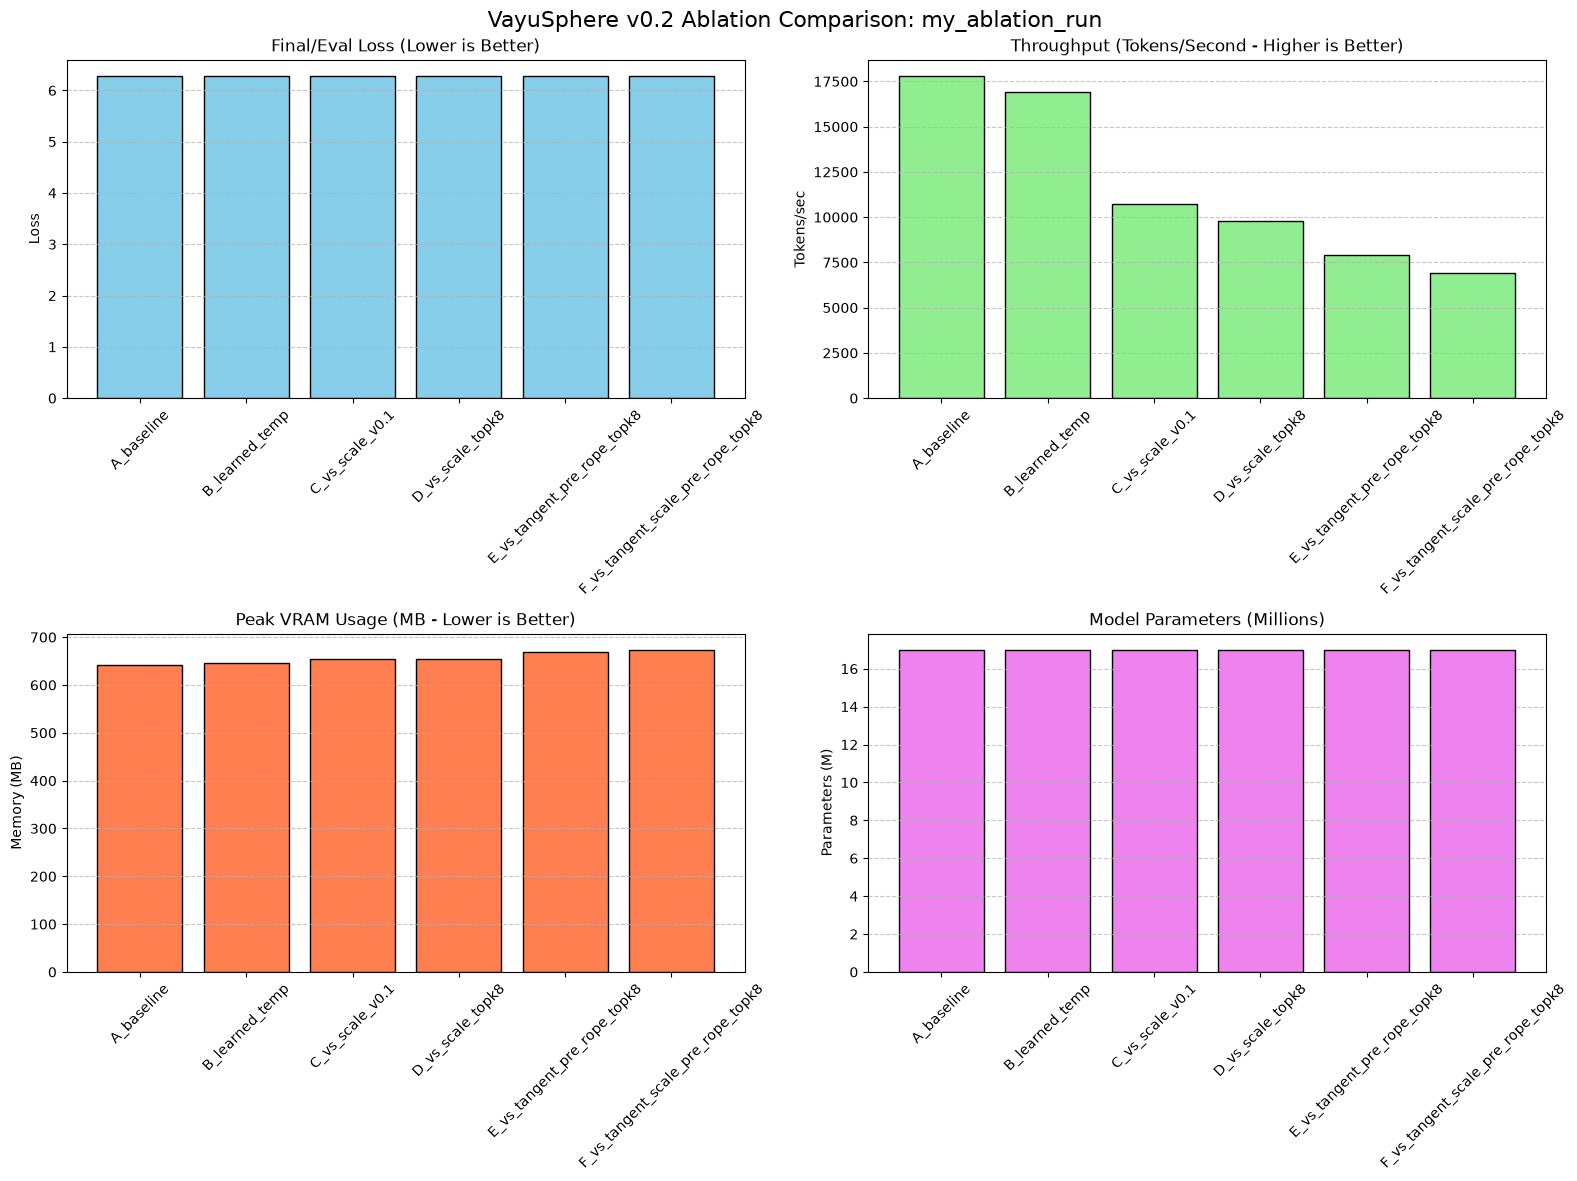

In [418]:
if run_to_analyze:
    summary_file = os.path.join(run_to_analyze, "ablation_results.csv")
    if os.path.exists(summary_file):
        df_summary = pd.read_csv(summary_file)
        
        # Plot side-by-side bar charts for Ablation metrics
        fig, axes = plt.subplots(2, 2, figsize=(16, 12))
        
        # 1. Best / Final Loss comparison
        axes[0, 0].bar(df_summary['name'], df_summary['loss'], color='skyblue', edgecolor='black')
        axes[0, 0].set_title("Final/Eval Loss (Lower is Better)")
        axes[0, 0].set_ylabel("Loss")
        axes[0, 0].tick_params(axis='x', rotation=45)
        axes[0, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        # 2. Training speed comparison
        axes[0, 1].bar(df_summary['name'], df_summary['tokens_per_sec'], color='lightgreen', edgecolor='black')
        axes[0, 1].set_title("Throughput (Tokens/Second - Higher is Better)")
        axes[0, 1].set_ylabel("Tokens/sec")
        axes[0, 1].tick_params(axis='x', rotation=45)
        axes[0, 1].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        # 3. Peak VRAM memory
        axes[1, 0].bar(df_summary['name'], df_summary['peak_mem_mb'], color='coral', edgecolor='black')
        axes[1, 0].set_title("Peak VRAM Usage (MB - Lower is Better)")
        axes[1, 0].set_ylabel("Memory (MB)")
        axes[1, 0].tick_params(axis='x', rotation=45)
        axes[1, 0].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        # 4. Parameters count
        axes[1, 1].bar(df_summary['name'], df_summary['params'] / 1e6, color='violet', edgecolor='black')
        axes[1, 1].set_title("Model Parameters (Millions)")
        axes[1, 1].set_ylabel("Parameters (M)")
        axes[1, 1].tick_params(axis='x', rotation=45)
        axes[1, 1].grid(True, axis='y', linestyle='--', alpha=0.7)
        
        plt.suptitle(f"VayuSphere v0.2 Ablation Comparison: {os.path.basename(run_to_analyze)}", fontsize=16, y=0.98)
        plt.tight_layout()
        plt.show()

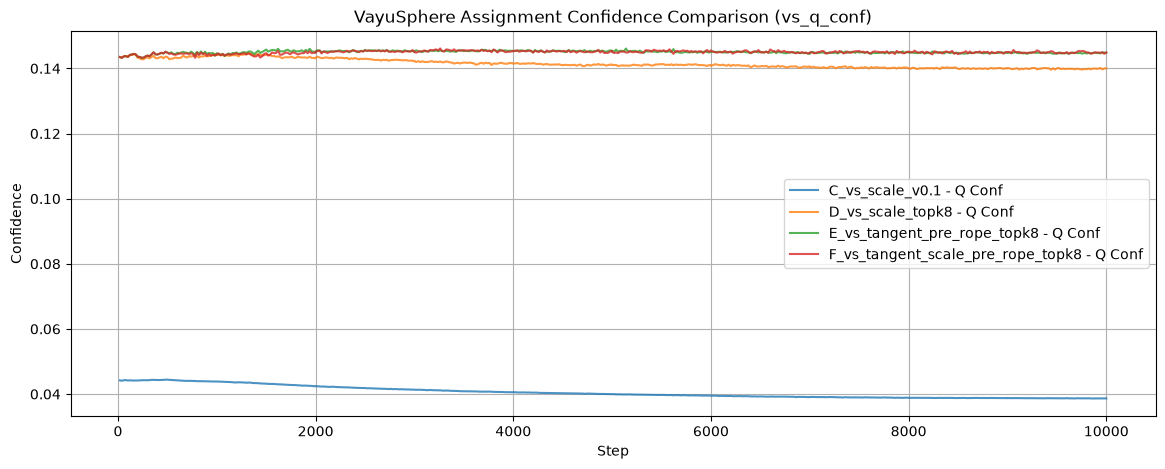

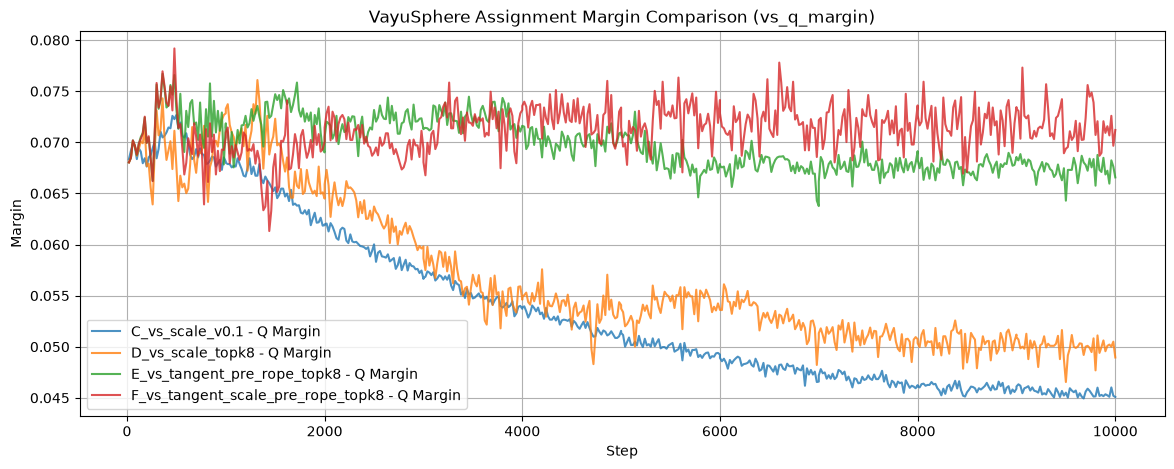

In [419]:
if run_to_analyze:
    subdirs = [d for d in os.listdir(run_to_analyze) if os.path.isdir(os.path.join(run_to_analyze, d))]
    
    # We want to plot gate confidences side-by-side for all active variants
    plt.figure(figsize=(14, 5))
    has_plots = False
    
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_conf' in df and not df['vs_q_conf'].dropna().empty:
                plt.plot(df['step'], df['vs_q_conf'].interpolate(), label=f"{subdir} - Q Conf", alpha=0.8)
                has_plots = True
                
    if has_plots:
        plt.title("VayuSphere Assignment Confidence Comparison (vs_q_conf)")
        plt.xlabel("Step")
        plt.ylabel("Confidence")
        plt.legend()
        plt.grid(True)
        plt.show()
        
    # Same for routing margins
    plt.figure(figsize=(14, 5))
    has_plots = False
    for subdir in subdirs:
        metrics_file = os.path.join(run_to_analyze, subdir, "metrics.csv")
        if os.path.exists(metrics_file):
            df = pd.read_csv(metrics_file)
            if 'vs_q_margin' in df and not df['vs_q_margin'].dropna().empty:
                plt.plot(df['step'], df['vs_q_margin'].interpolate(), label=f"{subdir} - Q Margin", alpha=0.8)
                has_plots = True
                
    if has_plots:
        plt.title("VayuSphere Assignment Margin Comparison (vs_q_margin)")
        plt.xlabel("Step")
        plt.ylabel("Margin")
        plt.legend()
        plt.grid(True)
        plt.show()